In [1]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..')))
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [33]:

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from src.data_handling.dataset import ECGDataset, ECGAugmentation
import torch
from src.model import (
    TransformerAutoencoder,
    patch_proj,
    patch_proj_inv,
)
from torch.utils.data import DataLoader
import json

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd()))
ROOT_DIR = os.path.join(BASE_DIR, '..')
DATA_DIR =  os.path.join(ROOT_DIR, 'Data')

In [56]:
preprocessed_data_dir = os.path.join(DATA_DIR, 'input', 'preprocessed_data',"fs250_bp0.5-45Hz")
json_split_path = os.path.join(DATA_DIR, 'input', 'experiment', '1.json')

# Double channel (MLII + V1)
train_transfrom = ECGAugmentation(preset='ssl')
    
ds2 = ECGDataset(
    data_dir=preprocessed_data_dir,
    transform=train_transfrom,
    window_size=256,
    json_file_path=json_split_path,      
    mode="ssl")

ds1 = ECGDataset(preprocessed_data_dir, window_size=256, json_file_path=json_split_path, mode="ssl", split='val')



Loading data for 1 patients from 'train' split...
Loading data for 1 patients from 'val' split...


In [25]:
model_path1 = os.path.join(DATA_DIR, 'output','mae_beat', 'checkpoint_epoch_100.pt')
model_path2 = os.path.join(DATA_DIR, 'output','encoder','beat_centered_64_16', 'best_model.pt')
model_path3 = os.path.join(DATA_DIR, 'output','encoder','beat_centered_128_16_75', 'best_model.pt')



model1 = TransformerAutoencoder(
        in_channels=2,
        emb_size=128,
        patch_size=16,
        num_layers=2,
        nhead=4,
        max_len=256
    )

model2 = TransformerAutoencoder(
        in_channels=2,
        emb_size=64,
        patch_size=16,
        num_layers=2,
        nhead=4,
        max_len=256
    )

model3 = TransformerAutoencoder(
        in_channels=2,
        emb_size=128,
        patch_size=16,
        num_layers=2,
        nhead=4,
        max_len=256
    )

model_saved1 = torch.load(model_path1, 
    map_location='cpu',  # Safest default device to map to
    weights_only=False   # Overrides the security check
    )
model1.load_state_dict(model_saved1["model_state_dict"])
model1.eval()

model_saved2 = torch.load(model_path2, 
    map_location='cpu',  # Safest default device to map to
    weights_only=False   # Overrides the security check
    )
model2.load_state_dict(model_saved2["model_state_dict"])
model2.eval()

model_saved3 = torch.load(model_path3, 
    map_location='cpu',  # Safest default device to map to
    weights_only=False   # Overrides the security check
    )
model3.load_state_dict(model_saved3["model_state_dict"])
model3.eval()

TransformerAutoencoder(
  (encoder_embed): PatchEmbedding1D(
    (proj): Conv1d(2, 128, kernel_size=(16,), stride=(16,))
    (pos_emb_generator): PositionalEncoding(
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder_pos_embed): LearnedPositionalEmbedding()
  (decoder): Transfo

In [125]:
import matplotlib.pyplot as plt
import torch
import numpy as np

@torch.no_grad()
def visualize_mae_reconstruction(model, x, leads=['MLII', 'V1'], mask_ratio=0.4, sample_idx=0):
    """
    Visualize MAE reconstruction for a 1D signal, showing recovered signals
    only for masked patches.
    """
    model.eval()
    device = next(model.parameters()).device
    x = x.to(device)

    # forward pass
    out = model(x, mask_ratio=mask_ratio)
    recon_patches = out['recon']                # [B, num_patches, C*P]
    ids_mask, ids_keep = out['mask']
    B, C, T = x.shape
    patch_size = model.patch_size

    # reconstruct full signals
    recon_signal = patch_proj_inv(recon_patches, C, patch_size)[sample_idx].cpu().squeeze()
    true_signal = x[sample_idx].cpu().squeeze()

    # determine masked regions
    num_patches = recon_patches.shape[1]
    masked_patches = ids_mask[sample_idx].cpu().numpy()
    mask = np.zeros(num_patches, dtype=bool)
    mask[masked_patches] = True

    # expand mask to time dimension
    time_mask = np.repeat(mask, patch_size)[:T]

    # only keep reconstructed signal for masked areas
    recon_masked_only = np.where(time_mask, recon_signal, np.nan)

    # --- plot
    fig, axes = plt.subplots(C, 1, figsize=(10, 2*C), sharex=True)
    if C == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(true_signal[i], label="Original", color='black', linewidth=2, alpha=0.6, linestyle='--')
        ax.plot(recon_masked_only[i], label="Reconstruction (masked only)", color='tab:red', alpha=0.8)

        
        # highlight masked regions
        for p_idx in masked_patches:
            start, end = p_idx * patch_size, (p_idx + 1) * patch_size
            ax.axvspan(start, end, color='gray', alpha=0.15)
        
        if leads:
            ax.set_ylabel(leads[i])
            ax.set_xlabel("Time steps")
        ax.grid(True, linestyle="--", alpha=0.5)

    fig.suptitle(f"MAE 1D Reconstruction (mask_ratio={mask_ratio:.2f}) — Showing masked regions only")
    plt.legend()
    plt.tight_layout()
    plt.show()


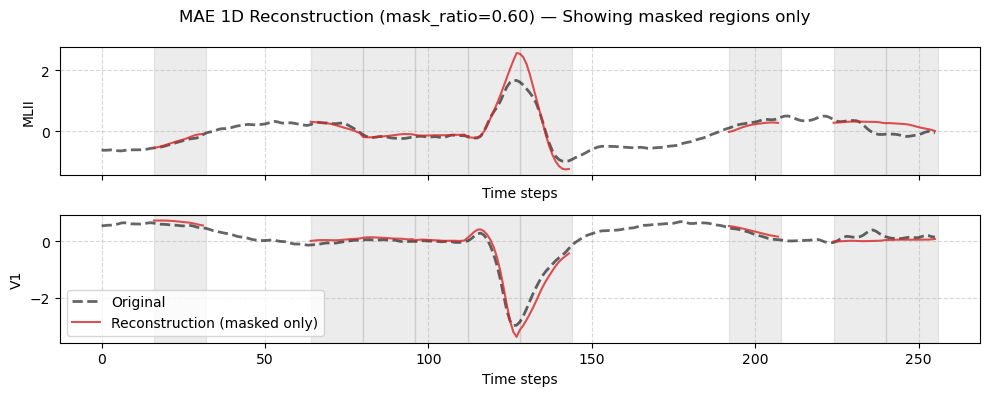

In [143]:
ssl_loader = DataLoader(ds1, batch_size=4)
signals_val = next(iter(ssl_loader))  # shape: [B, C, T]

visualize_mae_reconstruction(model1, signals_val, mask_ratio=0.6, sample_idx=0)


## Training History

In [85]:
history_path=os.path.join(DATA_DIR, 'output','encoder','beat_centered_64_16', 'history.json')

with open(history_path, 'r') as f:
            history = json.load(f)


In [86]:
print(history)

{'train_loss': [0.9787308560114473, 0.8125433731296835, 0.6422778954516807, 0.5531074040012273, 0.48124707112573595, 0.43632965776473964, 0.40954980390256945, 0.37963322294901497, 0.35948071482519034, 0.3466124654360558, 0.33180173925340994, 0.3254014135223545, 0.3122799010037287, 0.30530241567250255, 0.298048764603323, 0.2875742327813144, 0.28623262381172615, 0.2825753676564726, 0.26923943259944655, 0.2641805690037061, 0.2637284795443217, 0.2609856188569439, 0.25301916455025, 0.25387107346155874, 0.2445814652393942, 0.24211862676492021, 0.2440186542327001, 0.24114113631041628, 0.23808004275032374, 0.23226580370778907, 0.22932417180440198, 0.23726953484424174, 0.22795247786665615, 0.22796721382228208, 0.23142804389130578, 0.22251711799401672, 0.22183584105478574, 0.2225420269519771, 0.22484850271107398, 0.21895875533421835, 0.22004800565438729, 0.22119421542507328, 0.21486326181180945, 0.2159386514664785, 0.21737065523454588, 0.21220552261289397, 0.2101954049579629, 0.2069972188097157,

Training curves saved to training_curves.png


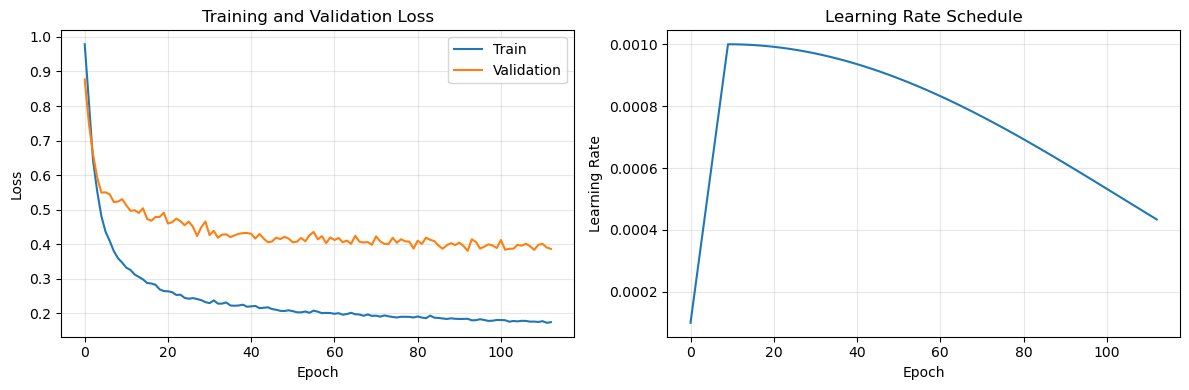

In [87]:
# Plot training curves    
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate
axes[1].plot(history['learning_rate'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
print("Training curves saved to training_curves.png")
plt.show()

In [88]:
ssl_loader = DataLoader(ds2, batch_size=32)
signals_train = next(iter(ssl_loader))  # shape: [B, C, T]

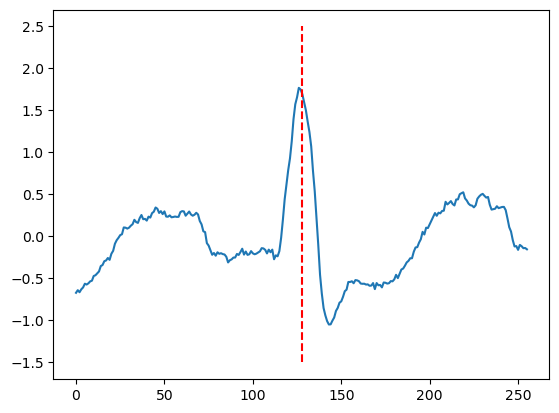

In [93]:
plt.plot(signals_train[0][0])  # Plot the first channel of the first sample
plt.vlines(x=[128], ymin=-1.5, ymax=2.5, linestyles='--', colors='red')